In [1]:
!pip install -q -U langgraph langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.5/571.5 kB 18.5 MB/s eta 0:00:00


In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command


class AgentState(TypedDict):
    user_input: str
    classification: str
    response: str

In [3]:
def classify(state: AgentState):
    text = state["user_input"].lower()

    if any(word in text for word in [
        "code", "python", "langgraph", "api", "programming", "error"
    ]):
        classification = "technical"

    elif any(word in text for word in [
        "urgent", "complaint", "refund", "human", "manager"
    ]):
        classification = "human_review"

    else:
        classification = "general"

    print(f"Classification: {classification}")

    return {
        "classification": classification
    }


In [4]:
def route(state: AgentState):
    print(f"Routing request as: {state['classification']}")

    return state


In [5]:
def respond(state: AgentState):
    classification = state["classification"]

    if classification == "technical":
        response = (
            "This is a technical request. "
            "I would provide a technical solution or debugging assistance."
        )

    elif classification == "general":
        response = (
            "This is a general request. "
            "I would provide a general informational response."
        )

    else:
        response = (
            "This request requires human review."
        )

    print(f"Response: {response}")

    return {
        "response": response
    }


In [6]:
def human_review(state: AgentState):
    print("⏸️ Graph paused. Waiting for human input...")

    human_decision = interrupt({
        "message": "Please review this request and provide your decision.",
        "user_input": state["user_input"],
        "classification": state["classification"]
    })

    print(f"Human decision: {human_decision}")

    return {
        "response": f"Human review completed: {human_decision}"
    }


In [7]:
def conditional_route(state: AgentState):
    if state["classification"] == "human_review":
        return "human_review"

    return "respond"


In [8]:
builder = StateGraph(AgentState)

# Add nodes
builder.add_node("classify", classify)
builder.add_node("route", route)
builder.add_node("respond", respond)
builder.add_node("human_review", human_review)

# Start -> classify
builder.add_edge(START, "classify")

# classify -> route
builder.add_edge("classify", "route")

# route -> conditional destination
builder.add_conditional_edges(
    "route",
    conditional_route,
    {
        "respond": "respond",
        "human_review": "human_review"
    }
)

# End points
builder.add_edge("respond", END)
builder.add_edge("human_review", END)

graph = builder.compile()


In [9]:
test_inputs = [
    "How do I write a Python function?",
    "What is artificial intelligence?",
    "I have an API error in my application.",
    "Can you explain LangGraph?",
    "I want a refund and need to speak to a human."
]

for i, text in enumerate(test_inputs, 1):
    print("\n" + "=" * 60)
    print(f"TEST {i}")
    print("=" * 60)

    result = graph.invoke({
        "user_input": text
    })

    print("Input:", text)
    print("Classification:", result.get("classification"))
    print("Response:", result.get("response"))



TEST 1
Classification: technical
Routing request as: technical
Response: This is a technical request. I would provide a technical solution or debugging assistance.
Input: How do I write a Python function?
Classification: technical
Response: This is a technical request. I would provide a technical solution or debugging assistance.

TEST 2
Classification: general
Routing request as: general
Response: This is a general request. I would provide a general informational response.
Input: What is artificial intelligence?
Classification: general
Response: This is a general request. I would provide a general informational response.

TEST 3
Classification: technical
Routing request as: technical
Response: This is a technical request. I would provide a technical solution or debugging assistance.
Input: I have an API error in my application.
Classification: technical
Response: This is a technical request. I would provide a technical solution or debugging assistance.

TEST 4
Classification: technic

In [10]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph_with_interrupt = builder.compile(
    checkpointer=memory
)


In [11]:
config = {
    "configurable": {
        "thread_id": "demo-1"
    }
}

result = graph_with_interrupt.invoke(
    {
        "user_input": "I want a refund and need to speak to a human."
    },
    config
)

print(result)


Classification: human_review
Routing request as: human_review
⏸️ Graph paused. Waiting for human input...
{'user_input': 'I want a refund and need to speak to a human.', 'classification': 'human_review', '__interrupt__': [Interrupt(value={'message': 'Please review this request and provide your decision.', 'user_input': 'I want a refund and need to speak to a human.', 'classification': 'human_review'}, id='f8b8078c061841e774f9b41a67723ae5')]}


In [12]:
result = graph_with_interrupt.invoke(
    Command(
        resume="Approved. Please proceed with the refund."
    ),
    config
)

print("\nFinal Result:")
print(result)


⏸️ Graph paused. Waiting for human input...
Human decision: Approved. Please proceed with the refund.

Final Result:
{'user_input': 'I want a refund and need to speak to a human.', 'classification': 'human_review', 'response': 'Human review completed: Approved. Please proceed with the refund.'}


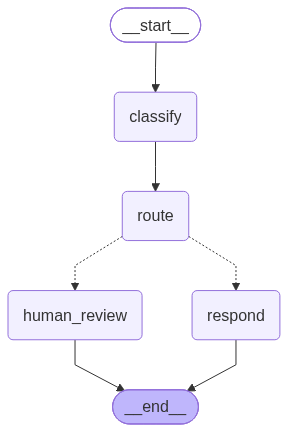

In [13]:
from IPython.display import Image, display

display(
    Image(
        graph_with_interrupt.get_graph().draw_mermaid_png()
    )
)
